> **Final reporting protocol note.** Earlier cells are preserved as exploratory/model-development cells. For thesis-comparable results, use the final section added at the end of this notebook: it evaluates with subject-independent grouped outer CV, reports mean ± std across folds, and uses task-level metrics with balanced accuracy as the primary metric. Inside each outer fold every model is tuned by an inner-CV grid search with **task-level balanced accuracy** as the selection objective; the per-model grids are aligned with the audio playground notebook so unimodal numbers across modalities live on the same hyperparameter budget. This matches the fusion-notebook protocol more closely than the earlier one-fold `next(...)` split cells.


# Exploracion del uso de features visuales extraidos con VLM

In [1]:
import os
from collections import OrderedDict

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score, recall_score, f1_score, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer

from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 123


In [2]:
cue_df = pd.read_csv("../results/Qwen3_VL_4B_Instruct_visual_cues_5s5fps_cropped_results.csv")
gt = pd.read_csv('../../labels_v2.csv', sep = ';')

cue_df

,subject,activity,window_id,head_movement,blink_behavior,eye_aperture,gaze_direction,gaze_stability,eyebrow_movement,mouth_shape,lip_pressing,lip_corner_tension,jaw_mouth_tension,visual_confidence,visual_summary
0,2ea4,Baseline,0,0,1,1,0,0,0,1,0,0,0,0.80,The subject maintains steady gaze with minimal...
1,2ea4,Baseline,1,0,1,1,0,0,0,1,0,0,0,0.85,Mild blinking and slight mouth tension are vis...
2,2ea4,Baseline,10,0,1,1,0,0,0,1,0,0,0,0.80,The subject exhibits mild blinking and slight ...
3,2ea4,Baseline,11,0,1,1,0,0,0,1,0,0,0,0.75,The subject shows mild blinking and slight eye...
4,2ea4,Baseline,2,0,1,1,0,0,0,1,0,0,0,0.70,The subject shows mild blinking and slight eye...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11419,y9z6,Video2,5,0,0,1,1,1,0,1,0,0,0,0.75,Mildly narrowed eyes and occasional downward g...
11420,y9z6,Video2,6,0,0,1,1,1,0,0,0,0,0,0.75,The subject shows mild eye narrowing and frequ...
11421,y9z6,Video2,7,0,1,1,0,1,0,1,0,0,0,0.75,The subject exhibits mild blinking and slight ...
11422,y9z6,Video2,8,0,0,1,0,0,0,0,0,0,0,0.80,"The subject maintains steady, direct gaze with..."


In [ ]:

CUE_COLS = [
    "head_movement",
    "blink_behavior",
    "eye_aperture",
    "gaze_direction",
    "gaze_stability",
    "eyebrow_movement",
    "mouth_shape",
    "lip_pressing",
    "lip_corner_tension",
    "jaw_mouth_tension",
]

LABEL_COLS = [
    "subject",
    "subject_activity",
    "subject/task",
    "binary-stress",
    "affect3-class",
    "affect3-class-v2",
]

SPOKEN_ACTIVITIES = [
    "Counting1",
    "Counting2",
    "Counting3",
    "Math",
    "Stroop",
    "Reading",
    "Speaking",
]


def activity_from_subject_activity(subject_activity):
    """Extract the activity name from ids such as 2ea4_Counting1"""
    value = str(subject_activity)
    return value.split("_", 1)[1] if "_" in value else value


def add_subject_activity(df, subject_col="subject", activity_col="activity"):
    """Ensure the visual-cue dataframe has the same task key used by labels"""
    out = df.copy()
    if "subject_activity" not in out.columns:
        out["subject_activity"] = (
            out[subject_col].astype(str) + "_" + out[activity_col].astype(str)
        )
    return out


def filter_to_activities(df, activities, activity_col="activity", task_col="subject_activity"):
    """Filter a dataframe to a list of activities without permanently adding helper columns"""
    if activities is None:
        return df.copy()

    activities = set(map(str, activities))
    out = df.copy()

    if activity_col in out.columns:
        mask = out[activity_col].astype(str).isin(activities)
    elif task_col in out.columns:
        mask = out[task_col].apply(activity_from_subject_activity).isin(activities)
    else:
        raise ValueError(
            f"Cannot filter by activity: neither '{activity_col}' nor '{task_col}' exists."
        )

    return out.loc[mask].copy()


def prepare_visual_cue_windows(cue_df, cue_cols=CUE_COLS, activities=None):
    """Clean window-level VLM visual-cue annotations and optionally keep only selected activities"""
    df = add_subject_activity(cue_df)
    df = filter_to_activities(df, activities) if activities is not None else df

    df[cue_cols] = df[cue_cols].apply(pd.to_numeric, errors="coerce")
    df = df.dropna(subset=cue_cols)
    df = df[(df[cue_cols] >= 0).all(axis=1)].copy()

    return df


def flatten_agg_columns(columns):
    return [f"{feature}_{stat}" for feature, stat in columns]


def build_task_level_cue_dataset(
    cue_df,
    gt,
    feature_aggs=("mean", "std", "max"),
    cue_cols=CUE_COLS,
    activities=None,
):
    """Aggregate window-level visual cues into one task-level feature vector per subject/activity"""
    df = prepare_visual_cue_windows(cue_df, cue_cols=cue_cols, activities=activities)

    agg = df.groupby(["subject", "subject_activity"])[cue_cols].agg(feature_aggs)
    agg.columns = flatten_agg_columns(agg.columns)
    agg = agg.reset_index()

    # std is NaN when there is only one window
    std_cols = [c for c in agg.columns if c.endswith("_std")]
    agg[std_cols] = agg[std_cols].fillna(0)

    dataset = gt.merge(agg, left_on="subject/task", right_on="subject_activity", how="inner")
    dataset = filter_to_activities(dataset, activities) if activities is not None else dataset

    return dataset


def get_task_level_xy_groups(df_task, drop_confidence=True):
    """Create X/y/groups for task-level visual-cue experiments, where X are the features, y is the label, and groups are the subjects"""
    drop_cols = LABEL_COLS.copy()

    if drop_confidence:
        drop_cols += CONFIDENCE_FEATURES

    X = df_task.drop(columns=drop_cols, errors="ignore")
    y = df_task["binary-stress"].astype(int)
    groups = df_task["subject"]

    return X, y, groups


def safe_inner_group_cv(y, groups, max_splits=3):
    """Use as many inner folds as the class and group counts safely allow, but keep the maximum as 3"""
    y = pd.Series(y)
    groups = pd.Series(groups)

    min_class_count = int(y.value_counts().min())
    n_groups = int(groups.nunique())
    n_splits = min(max_splits, min_class_count, n_groups)

    if n_splits < 2:
        raise ValueError(
            "Not enough classes/groups to build an inner StratifiedGroupKFold split"
        )

    return StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )


def tune_threshold(y_true, probs, thresholds=np.arange(0.1, 0.9, 0.02)):
    """Tune the decision threshold"""
    best_thresh = 0.5
    best_b_acc = 0

    for thresh in thresholds:
        preds = (probs >= thresh).astype(int)
        b_acc = balanced_accuracy_score(y_true, preds)

        if b_acc >= best_b_acc:
            best_b_acc = b_acc
            best_thresh = thresh

    return best_thresh, best_b_acc


def classification_metrics(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)

    return {
        "Bal_Acc": round(balanced_accuracy_score(y_true, preds), 4),
        "Accuracy": round(accuracy_score(y_true, preds), 2),
        "F1": round(f1_score(y_true, preds), 2),
        "Rec_NoStress": round(recall_score(y_true, preds, pos_label=0, zero_division=0), 2),
        "Rec_Stress": round(recall_score(y_true, preds, pos_label=1, zero_division=0), 2),
    }


def make_task_level_models(y_train):
    """Models used in the task-level feature-aggregation experiment"""
    scale_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    return OrderedDict({
        "Logistic Regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),

        "Random Forest": RandomForestClassifier(
            class_weight="balanced",
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),

        "Balanced Random Forest": BalancedRandomForestClassifier(
            n_estimators=300,
            sampling_strategy="auto",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),

        "XGBoost": XGBClassifier(
            scale_pos_weight=scale_weight,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),

        "MLP Probe": make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            MLPClassifier(
                hidden_layer_sizes=(32, 8),
                activation="relu",
                alpha=1e-3,
                learning_rate_init=1e-3,
                max_iter=1000,
                early_stopping=True,
                random_state=RANDOM_STATE,
            ),
        ),
    })


def make_window_level_models(y_train):
    """Models used in the window-level prediction + task-level aggregation experiment"""
    scale_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    return OrderedDict({
        "Logistic Regression": make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),

        "Random Forest": RandomForestClassifier(
            class_weight="balanced",
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),

        "Balanced Random Forest": make_pipeline(
            SimpleImputer(strategy="median"),
            BalancedRandomForestClassifier(
                n_estimators=300,
                sampling_strategy="auto",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),

        "XGBoost": make_pipeline(
            SimpleImputer(strategy="median"),
            XGBClassifier(
                scale_pos_weight=scale_weight,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    })


def first_subject_split(X, y, groups, n_splits=5):
    """Return the first split from the original subject-aware split setup"""
    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    return next(sgkf.split(X, y, groups))


def run_task_level_feature_experiment(df_task, n_splits=5, inner_splits=3):
    """Run the feature-level aggregation experiment"""
    X, y, groups = get_task_level_xy_groups(df_task, drop_confidence=True)
    train_idx, test_idx = first_subject_split(X, y, groups, n_splits=n_splits)

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]

    models = make_task_level_models(y_train)
    cv_train = safe_inner_group_cv(y_train, groups_train, max_splits=inner_splits)

    results_list = []

    for model_name, model in models.items():
        model.fit(X_train, y_train)

        test_probs = model.predict_proba(X_test)[:, 1]
        train_unbiased_probs = cross_val_predict(
            clone(model),
            X_train,
            y_train,
            groups=groups_train,
            cv=cv_train,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

        best_thresh, _ = tune_threshold(y_train, train_unbiased_probs)
        row = {
            "Model": model_name,
            "Thresh": round(best_thresh, 2),
            **classification_metrics(y_test, test_probs, best_thresh),
            "N_Test": len(y_test),
        }
        results_list.append(row)

    comparison_df = (
        pd.DataFrame(results_list)
        .sort_values("Bal_Acc", ascending=False)
        .reset_index(drop=True)
    )

    split_data = {
        "X": X,
        "y": y,
        "groups": groups,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "groups_train": groups_train,
    }

    return comparison_df, models, split_data


def fit_and_get_feature_importance(model, X_train, y_train):
    """Fit a model and return the feature importance dataframe"""
    model.fit(X_train, y_train)

    if hasattr(model, "named_steps") and "logisticregression" in model.named_steps:
        coefs = model.named_steps["logisticregression"].coef_[0]
    elif hasattr(model, "named_steps") and "balancedrandomforestclassifier" in model.named_steps:
        coefs = model.named_steps["balancedrandomforestclassifier"].feature_importances_
    elif hasattr(model, "named_steps") and "xgbclassifier" in model.named_steps:
        coefs = model.named_steps["xgbclassifier"].feature_importances_
    elif hasattr(model, "feature_importances_"):
        coefs = model.feature_importances_
    else:
        raise ValueError(f"Feature importance is not implemented for {type(model)}")

    return pd.DataFrame({
        "feature": X_train.columns,
        "coef": coefs,
    }).sort_values("coef", ascending=False)


def build_window_level_cue_dataset(cue_df, gt, cue_cols=CUE_COLS, activities=None):
    """Prepare window-level visual cue rows with task-level labels merged in"""
    df = prepare_visual_cue_windows(cue_df, cue_cols=cue_cols, activities=activities)
    df = df.merge(gt, left_on="subject_activity", right_on="subject/task", how="inner")
    return df


def default_aggregation_strategies():
    return OrderedDict({
        "Mean": "mean",
        "Median": "median",
        "Max": "max",
        "75th_Percentile": lambda x: np.percentile(x, 75),
    })


def run_window_to_task_aggregation_experiment(
    df,
    cue_cols=CUE_COLS,
    n_splits=5,
    inner_splits=3,
    agg_strategies=None,
):
    """Run window-level prediction and aggregate probabilities to task-level decisions"""
    if agg_strategies is None:
        agg_strategies = default_aggregation_strategies()

    X = df[cue_cols]
    y = df["binary-stress"].astype(int)
    groups_subject = df["subject"]
    task_ids = df["subject_activity"]

    train_idx, test_idx = first_subject_split(X, y, groups_subject, n_splits=n_splits)

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups_subject.iloc[train_idx]
    task_train = task_ids.iloc[train_idx]
    task_test = task_ids.iloc[test_idx]

    models = make_window_level_models(y_train)
    cv_train = safe_inner_group_cv(y_train, groups_train, max_splits=inner_splits)

    results_list = []

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        test_probs = model.predict_proba(X_test)[:, 1]

        train_unbiased_probs = cross_val_predict(
            clone(model),
            X_train,
            y_train,
            groups=groups_train,
            cv=cv_train,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

        train_base_df = pd.DataFrame({
            "subject_activity": task_train.values,
            "true_label": y_train.values,
            "pred_prob": train_unbiased_probs,
        })

        test_base_df = pd.DataFrame({
            "subject_activity": task_test.values,
            "true_label": y_test.values,
            "pred_prob": test_probs,
        })

        for strategy_name, agg_func in agg_strategies.items():
            train_agg = train_base_df.groupby("subject_activity").agg(
                true_label=("true_label", "first"),
                agg_prob=("pred_prob", agg_func),
            ).reset_index()

            best_thresh, _ = tune_threshold(train_agg["true_label"], train_agg["agg_prob"])

            test_agg = test_base_df.groupby("subject_activity").agg(
                true_label=("true_label", "first"),
                agg_prob=("pred_prob", agg_func),
            ).reset_index()

            row = {
                "Model": model_name,
                "Strategy": strategy_name,
                "Thresh": round(best_thresh, 2),
                **classification_metrics(test_agg["true_label"], test_agg["agg_prob"], best_thresh),
                "N_Test_Tasks": test_agg["subject_activity"].nunique(),
            }
            results_list.append(row)

    comparison_df = (
        pd.DataFrame(results_list)
        .sort_values(by="Bal_Acc", ascending=False)
        .reset_index(drop=True)
    )

    split_data = {
        "X": X,
        "y": y,
        "groups_subject": groups_subject,
        "task_ids": task_ids,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "groups_train": groups_train,
        "task_train": task_train,
        "task_test": task_test,
    }

    return comparison_df, models, split_data


In [ ]:
cue_df = pd.read_csv("../results/Qwen3_VL_4B_Instruct_visual_cues_5s5fps_cropped_results.csv")

df_task = build_task_level_cue_dataset(
    cue_df,
    gt,
    feature_aggs=("mean", "std", "max")
)

comparison_df, models, task_split = run_task_level_feature_experiment(df_task)

X = task_split["X"]
y = task_split["y"]
groups = task_split["groups"]
train_idx = task_split["train_idx"]
test_idx = task_split["test_idx"]
X_train = task_split["X_train"]
X_test = task_split["X_test"]
y_train = task_split["y_train"]
y_test = task_split["y_test"]
groups_train = task_split["groups_train"]

print('Feature level agregation of visual cues obtained via VLM:')
print(comparison_df.to_string(index=False))


Feature level agregation of visual cues obtained via VLM:
                 Model  Thresh  Bal_Acc  Accuracy   F1  Rec_NoStress  Rec_Stress  N_Test
               XGBoost    0.36   0.6879      0.69 0.71          0.67        0.70     119
   Logistic Regression    0.50   0.6800      0.67 0.65          0.78        0.58     119
Balanced Random Forest    0.36   0.6788      0.68 0.70          0.65        0.70     119
         Random Forest    0.54   0.6761      0.67 0.67          0.73        0.62     119
             MLP Probe    0.38   0.6385      0.64 0.66          0.64        0.64     119


Importancia de features por modelo:

## Regresion Logistica:

Ordenamos por coeficiente:

                    feature      coef
4        blink_behavior_std  0.826027
24  lip_corner_tension_mean  0.797159
18         mouth_shape_mean  0.740434
7          eye_aperture_std  0.733157
0        head_movement_mean  0.628646
                   feature      coef
11      gaze_direction_max -0.334149
2        head_movement_max -0.375408
5       blink_behavior_max -0.396584
21       lip_pressing_mean -0.586795
27  jaw_mouth_tension_mean -0.638187


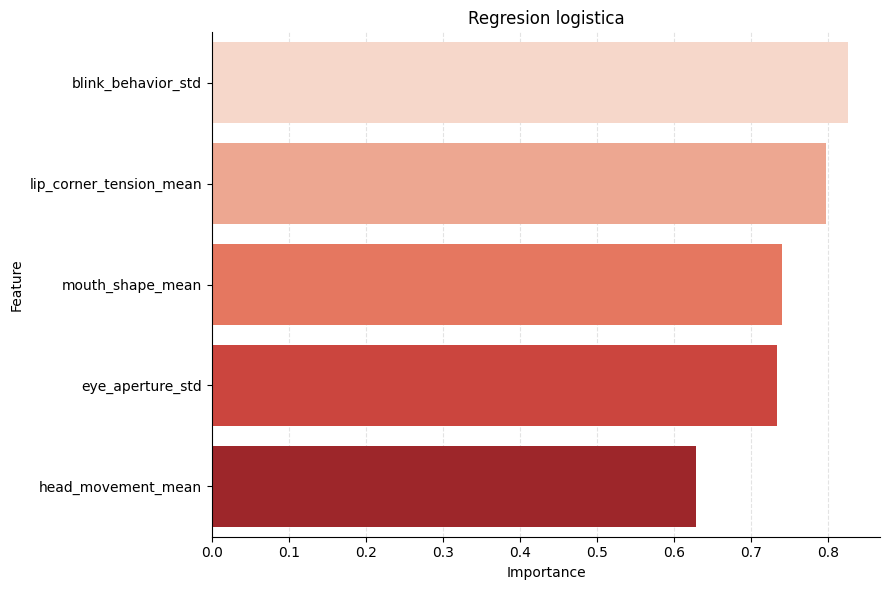

In [6]:
model = models["Logistic Regression"]
coef_df_log = fit_and_get_feature_importance(model, X_train, y_train)

print(coef_df_log.head(5))
print(coef_df_log.tail(5))
plot_feature_importance(coef_df_log, top_n=5, title = 'Regresion logistica')


## Random Forest:

                feature      coef
3   blink_behavior_mean  0.083524
4    blink_behavior_std  0.075888
7      eye_aperture_std  0.071515
13   gaze_stability_std  0.068502
18     mouth_shape_mean  0.064590
                   feature      coef
22        lip_pressing_std  0.010054
5       blink_behavior_max  0.009227
26  lip_corner_tension_max  0.006339
2        head_movement_max  0.005811
23        lip_pressing_max  0.003113


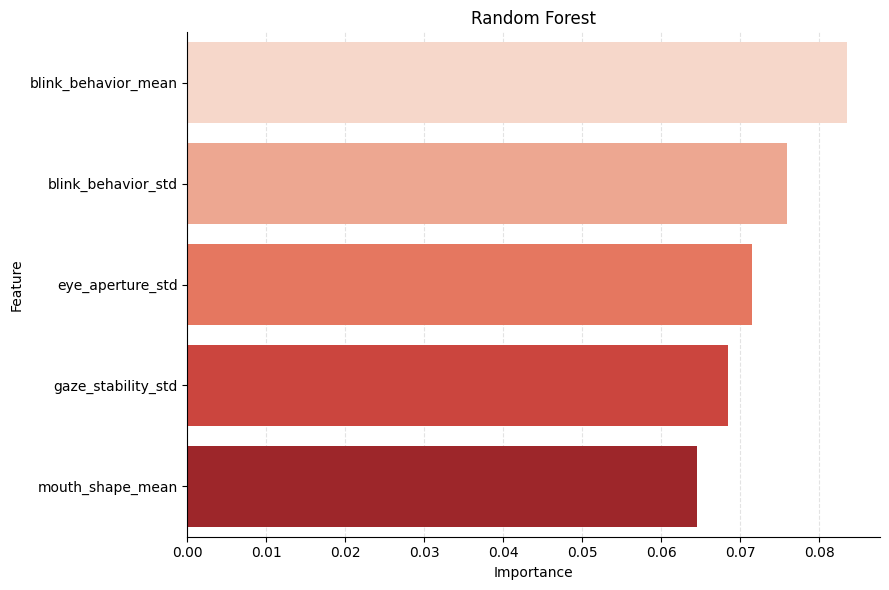

In [7]:
rf = models["Random Forest"]
coef_df_rf = fit_and_get_feature_importance(rf, X_train, y_train)

print(coef_df_rf.head(5))
print(coef_df_rf.tail(5))
plot_feature_importance(coef_df_rf, top_n=5, title = 'Random Forest')


## Balanced Random Forest:

                feature      coef
4    blink_behavior_std  0.093683
3   blink_behavior_mean  0.076349
7      eye_aperture_std  0.070386
13   gaze_stability_std  0.067088
18     mouth_shape_mean  0.065010
                   feature      coef
21       lip_pressing_mean  0.009308
26  lip_corner_tension_max  0.007517
5       blink_behavior_max  0.006683
2        head_movement_max  0.006011
23        lip_pressing_max  0.003654


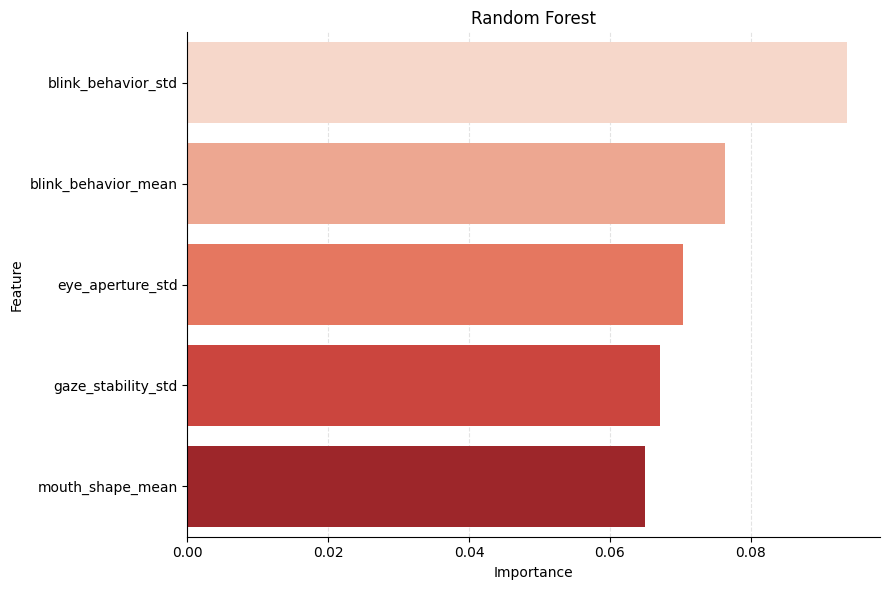

In [8]:
brf = models["Balanced Random Forest"]
coef_df_brf = fit_and_get_feature_importance(brf, X_train, y_train)

print(coef_df_brf.head(5))
print(coef_df_brf.tail(5))
plot_feature_importance(coef_df_brf, top_n=5, title = 'Random Forest')


## XGBoost:

                   feature      coef
26  lip_corner_tension_max  0.096292
4       blink_behavior_std  0.084432
16    eyebrow_movement_std  0.055809
28   jaw_mouth_tension_std  0.053888
21       lip_pressing_mean  0.053453
                  feature      coef
14     gaze_stability_max  0.006046
2       head_movement_max  0.000000
5      blink_behavior_max  0.000000
23       lip_pressing_max  0.000000
29  jaw_mouth_tension_max  0.000000


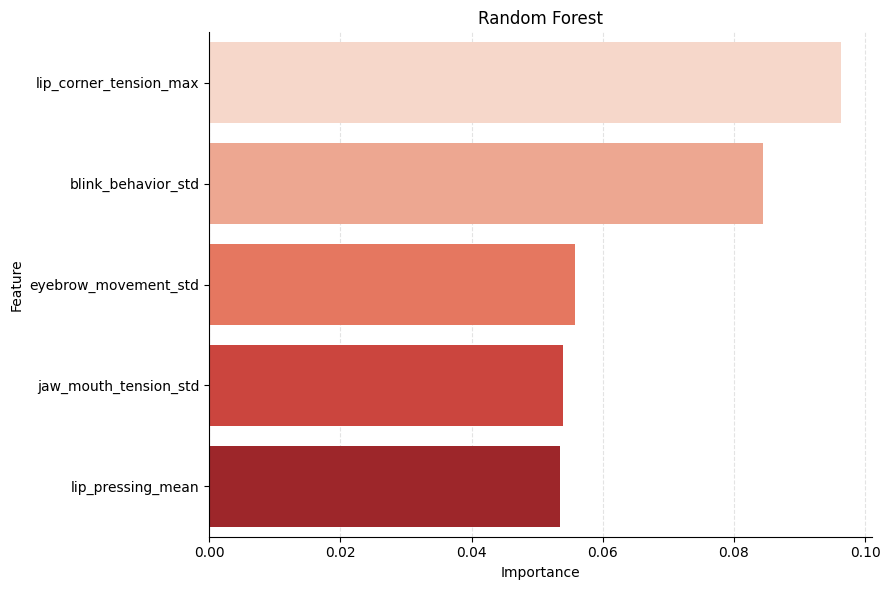

In [9]:
xgb_model = models["XGBoost"]
coef_df_xgb = fit_and_get_feature_importance(xgb_model, X_train, y_train)

print(coef_df_xgb.head(5))
print(coef_df_xgb.tail(5))
plot_feature_importance(coef_df_xgb, top_n=5, title = 'Random Forest')


## Window level prediction, Task level aggregation

In [10]:
cue_df = pd.read_csv("../results/Qwen3_VL_4B_Instruct_visual_cues_5s5fps_cropped_results.csv")

df_window = build_window_level_cue_dataset(cue_df, gt)

comparison_df, window_models, window_split = run_window_to_task_aggregation_experiment(df_window)

X = window_split["X"]
y = window_split["y"]
groups_subject = window_split["groups_subject"]
task_ids = window_split["task_ids"]
train_idx = window_split["train_idx"]
test_idx = window_split["test_idx"]
X_train = window_split["X_train"]
X_test = window_split["X_test"]
y_train = window_split["y_train"]
y_test = window_split["y_test"]
groups_train = window_split["groups_train"]
task_train = window_split["task_train"]
task_test = window_split["task_test"]
models = window_models

print(comparison_df.to_string(index=False))


                 Model        Strategy  Thresh  Bal_Acc  Accuracy   F1  Rec_NoStress  Rec_Stress  N_Test_Tasks
Balanced Random Forest            Mean    0.48   0.7523      0.75 0.77          0.77        0.74           120
Balanced Random Forest          Median    0.46   0.7483      0.76 0.79          0.67        0.82           120
         Random Forest            Mean    0.48   0.7398      0.73 0.75          0.79        0.69           120
Balanced Random Forest 75th_Percentile    0.56   0.7245      0.71 0.70          0.85        0.60           120
         Random Forest          Median    0.48   0.7206      0.72 0.73          0.75        0.69           120
               XGBoost          Median    0.48   0.7110      0.71 0.73          0.73        0.69           120
               XGBoost            Mean    0.46   0.7025      0.72 0.76          0.60        0.81           120
         Random Forest 75th_Percentile    0.54   0.6957      0.68 0.68          0.79        0.60           120
 

Sorprendentemente alto, pero al no estar usando CV, pues ser un lucky fold.

## Spoken/audio-available activity subset


In [11]:
spoken_activities = SPOKEN_ACTIVITIES

df_task_spoken = build_task_level_cue_dataset(
    cue_df,
    gt,
    feature_aggs=("mean", "std", "max"),
    activities=spoken_activities,
)

spoken_feature_comparison_df, spoken_models, spoken_task_split = run_task_level_feature_experiment(
    df_task_spoken
)

print("\nFeature level agregation of visual cues obtained via VLM, spoken/audio-available subset:")
print(spoken_feature_comparison_df.to_string(index=False))

df_window_spoken = build_window_level_cue_dataset(
    cue_df,
    gt,
    activities=spoken_activities,
)

spoken_window_comparison_df, spoken_window_models, spoken_window_split = run_window_to_task_aggregation_experiment(
    df_window_spoken
)

print("\nWindow level prediction, task level aggregation, spoken/audio-available subset:")
print(spoken_window_comparison_df.to_string(index=False))



Feature level agregation of visual cues obtained via VLM, spoken/audio-available subset:
                 Model  Thresh  Bal_Acc  Accuracy   F1  Rec_NoStress  Rec_Stress  N_Test
               XGBoost    0.64   0.5476      0.57 0.66          0.48        0.62      63
   Logistic Regression    0.18   0.5000      0.67 0.80          0.00        1.00      63
Balanced Random Forest    0.50   0.5000      0.46 0.48          0.62        0.38      63
             MLP Probe    0.42   0.4881      0.37 0.20          0.86        0.12      63
         Random Forest    0.78   0.4643      0.43 0.45          0.57        0.36      63

Window level prediction, task level aggregation, spoken/audio-available subset:
                 Model        Strategy  Thresh  Bal_Acc  Accuracy   F1  Rec_NoStress  Rec_Stress  N_Test_Tasks
   Logistic Regression            Mean    0.62   0.5000      0.33 0.00          1.00        0.00            63
   Logistic Regression          Median    0.88   0.5000      0.33 0.00   

## Spoken subset feature importances


## Logistic Regression
                    feature      coef
24  lip_corner_tension_mean  0.693270
17     eyebrow_movement_max  0.673301
7          eye_aperture_std  0.605161
9       gaze_direction_mean  0.590038
0        head_movement_mean  0.475749
                   feature      coef
29   jaw_mouth_tension_max -0.390641
25  lip_corner_tension_std -0.451922
21       lip_pressing_mean -0.556137
11      gaze_direction_max -0.566437
27  jaw_mouth_tension_mean -0.577332


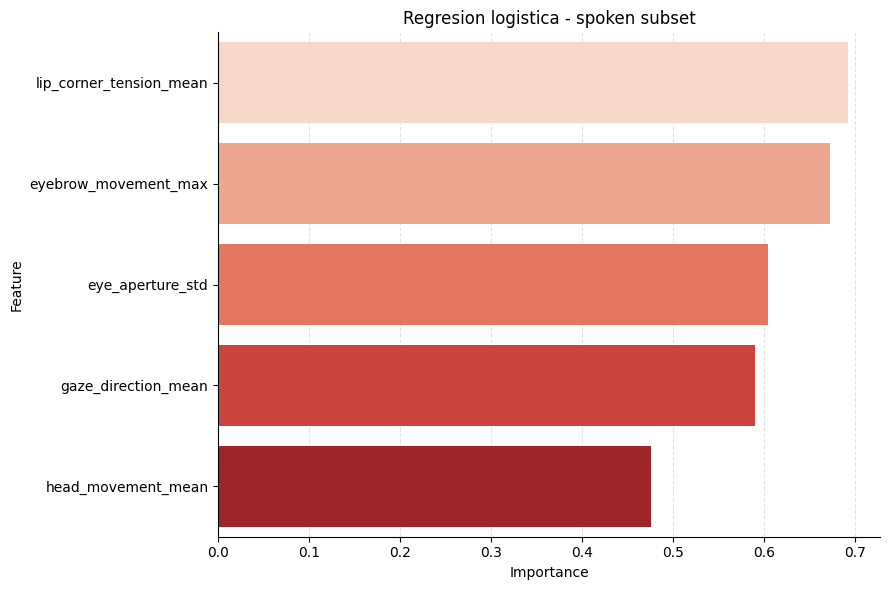


## Random Forest
                feature      coef
9   gaze_direction_mean  0.082937
3   blink_behavior_mean  0.074901
12  gaze_stability_mean  0.065758
4    blink_behavior_std  0.063701
7      eye_aperture_std  0.063056
                    feature      coef
5        blink_behavior_max  0.011889
24  lip_corner_tension_mean  0.011682
2         head_movement_max  0.008928
26   lip_corner_tension_max  0.007578
23         lip_pressing_max  0.006276


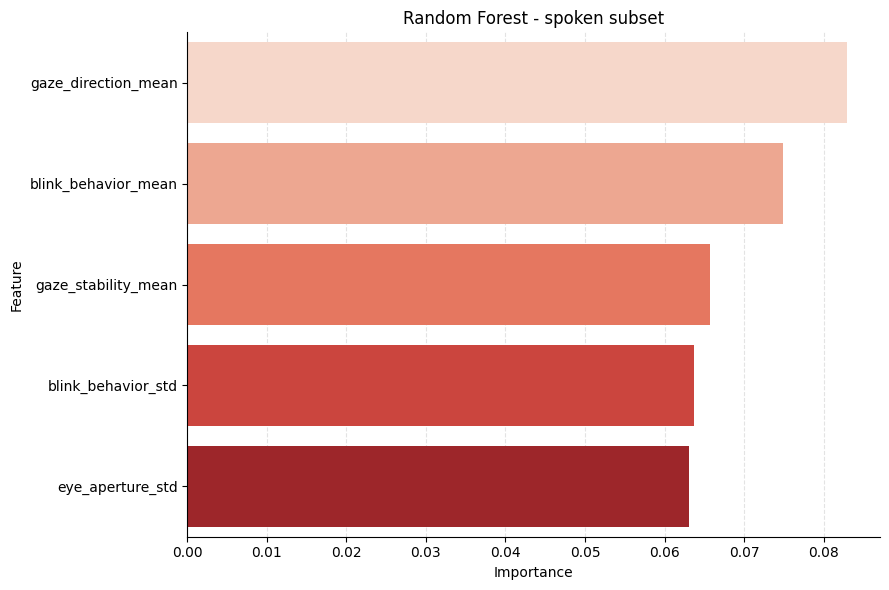


## Balanced Random Forest
                feature      coef
3   blink_behavior_mean  0.079083
9   gaze_direction_mean  0.075337
12  gaze_stability_mean  0.064810
4    blink_behavior_std  0.062016
10   gaze_direction_std  0.061805
                   feature      coef
5       blink_behavior_max  0.011177
21       lip_pressing_mean  0.011051
26  lip_corner_tension_max  0.008888
2        head_movement_max  0.008096
23        lip_pressing_max  0.005467


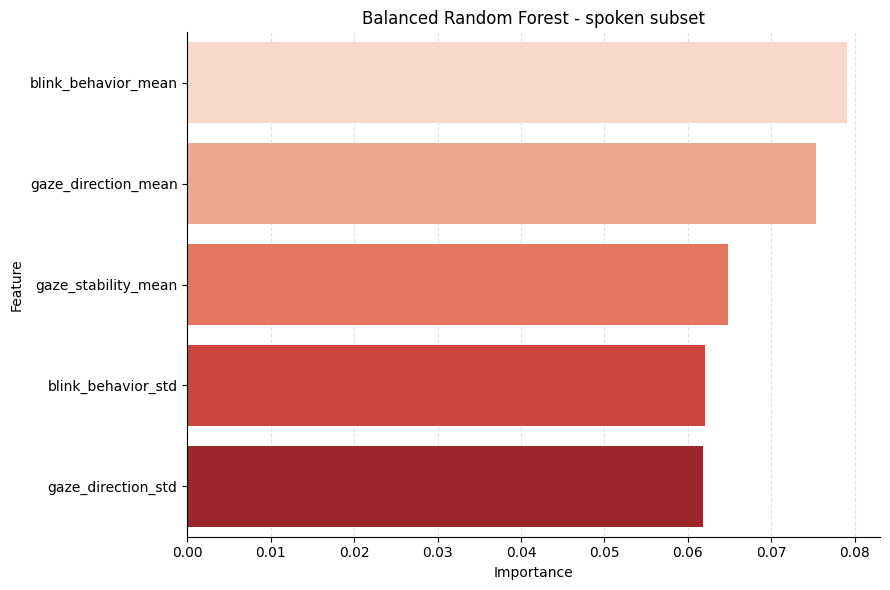


## XGBoost
                  feature      coef
22       lip_pressing_std  0.149039
28  jaw_mouth_tension_std  0.072735
1       head_movement_std  0.068949
7        eye_aperture_std  0.058235
19        mouth_shape_std  0.047864
                   feature  coef
5       blink_behavior_max   0.0
2        head_movement_max   0.0
23        lip_pressing_max   0.0
26  lip_corner_tension_max   0.0
29   jaw_mouth_tension_max   0.0


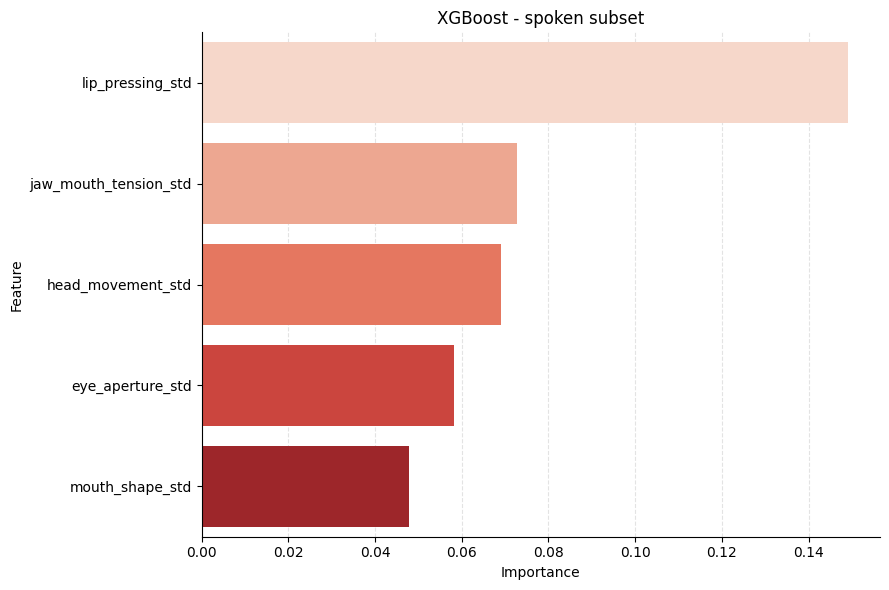

In [12]:
X_train_spoken = spoken_task_split["X_train"]
y_train_spoken = spoken_task_split["y_train"]

spoken_importance_dfs = {}

for model_name, title in [
    ("Logistic Regression", "Regresion logistica - spoken subset"),
    ("Random Forest", "Random Forest - spoken subset"),
    ("Balanced Random Forest", "Balanced Random Forest - spoken subset"),
    ("XGBoost", "XGBoost - spoken subset"),
]:
    print(f"\n## {model_name}")
    coef_df = fit_and_get_feature_importance(spoken_models[model_name], X_train_spoken, y_train_spoken)
    spoken_importance_dfs[model_name] = coef_df

    print(coef_df.head(5))
    print(coef_df.tail(5))
    plot_feature_importance(coef_df, top_n=5, title=title)


## Subject-independent CV evaluation

In [ ]:
# ============================================================
# Subject-independent 5-fold outer CV, task-level metrics mainly BA
#
#   - For the task-level feature experiment, samples are already
#     tasks, so GridSearchCV(scoring="balanced_accuracy") is
#     task-level scoring directly.
#   - For the window-level experiment, window probabilities are
#     aggregated to task level inside the inner CV before scoring. The outer fold then
#     evaluates the tuned model under all four aggregation
#     strategies, so hyperparameter selection is decoupled from
#     the final aggregation choice.
# ============================================================

from collections import OrderedDict

from sklearn.base import clone
from sklearn.metrics import precision_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

OUTER_SPLITS = 5
INNER_SPLITS = 3
THRESHOLDS = np.arange(0.1, 0.9, 0.02)

# Aggregation function used INSIDE the inner-CV grid search to score
# candidates at the task level. The outer fold separately evaluates all
# aggregation strategies. Mean is used because it is the standard, and stable inner-objective choice
INNER_SCORING_AGG = "mean"
# Fixed threshold used inside the inner CV when ranking candidates. Kept
# at 0.5 so hyperparameter selection is decoupled from threshold tuning
INNER_SCORING_THRESHOLD = 0.5


def safe_outer_group_cv(y, groups, max_splits=5):
    y = pd.Series(y).reset_index(drop=True)
    groups = pd.Series(groups).reset_index(drop=True)
    n_splits = min(max_splits, int(y.value_counts().min()), int(groups.nunique()))
    if n_splits < 2:
        raise ValueError("Not enough class examples/groups for grouped cross-validation.")
    return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


def compute_cv_metrics(y_true, probs, threshold):
    y_true = pd.Series(y_true).astype(int).to_numpy()
    probs = np.asarray(probs)
    preds = (probs >= threshold).astype(int)
    row = {
        "accuracy": accuracy_score(y_true, preds),
        "balanced_accuracy": balanced_accuracy_score(y_true, preds),
        "f1": f1_score(y_true, preds, zero_division=0),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall_no_stress": recall_score(y_true, preds, pos_label=0, zero_division=0),
        "recall_stress": recall_score(y_true, preds, pos_label=1, zero_division=0),
    }
    row["roc_auc"] = roc_auc_score(y_true, probs) if len(np.unique(y_true)) == 2 else np.nan
    return row


def summarize_visual_cv(fold_df, group_cols):
    metric_cols = [
        "accuracy", "balanced_accuracy", "f1", "precision",
        "recall_no_stress", "recall_stress", "roc_auc",
    ]
    rows = []
    for keys, group in fold_df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        for metric in metric_cols:
            row[f"{metric}_mean"] = group[metric].mean()
            row[f"{metric}_std"] = group[metric].std(ddof=1)
        row["n_folds"] = group["fold"].nunique()
        row["n_tasks_mean"] = group["n_test_tasks"].mean()
        rows.append(row)
    return (
        pd.DataFrame(rows)
        .sort_values(["balanced_accuracy_mean", "f1_mean", "accuracy_mean"], ascending=False)
        .reset_index(drop=True)
    )


def make_visual_task_models(y_train):
    """
    Default-configured pipelines for the task-level feature experiment.
    """
    scale_weight = (pd.Series(y_train).eq(0).sum()) / max(pd.Series(y_train).eq(1).sum(), 1)

    return OrderedDict({
        "Logistic Regression": make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
        ),
        "Random Forest": make_pipeline(
            SimpleImputer(strategy="median"),
            RandomForestClassifier(
                class_weight="balanced",
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
        "Balanced Random Forest": make_pipeline(
            SimpleImputer(strategy="median"),
            BalancedRandomForestClassifier(
                n_estimators=300,
                sampling_strategy="auto",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
        "XGBoost": make_pipeline(
            SimpleImputer(strategy="median"),
            XGBClassifier(
                scale_pos_weight=scale_weight,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
        "MLP Probe": make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            MLPClassifier(
                hidden_layer_sizes=(32, 8),
                activation="relu",
                alpha=1e-3,
                learning_rate_init=1e-3,
                max_iter=1000,
                early_stopping=True,
                random_state=RANDOM_STATE,
            ),
        ),
    })


def make_visual_window_models(y_train):
    """
    Default-configured pipelines for window-level feature importance.
    """
    return make_visual_task_models(y_train)


def make_visual_model_grids(y_train):
    """
    (pipeline, param_grid) per model used by the nested-CV main eval.

    """
    scale_weight = (pd.Series(y_train).eq(0).sum()) / max(pd.Series(y_train).eq(1).sum(), 1)

    return OrderedDict({
        "Logistic Regression": (
            make_pipeline(
                SimpleImputer(strategy="median"),
                StandardScaler(),
                LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
            ),
            {
                "logisticregression__C": [0.01, 0.1, 1.0, 10.0],
            },
        ),
        "Random Forest": (
            make_pipeline(
                SimpleImputer(strategy="median"),
                RandomForestClassifier(
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                ),
            ),
            {
                "randomforestclassifier__n_estimators": [200, 500],
                "randomforestclassifier__max_depth": [None, 5, 10],
                "randomforestclassifier__min_samples_leaf": [1, 3],
            },
        ),
        "Balanced Random Forest": (
            make_pipeline(
                SimpleImputer(strategy="median"),
                BalancedRandomForestClassifier(
                    sampling_strategy="auto",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                ),
            ),
            {
                "balancedrandomforestclassifier__n_estimators": [200, 500],
                "balancedrandomforestclassifier__max_depth": [None, 5, 10],
                "balancedrandomforestclassifier__min_samples_leaf": [1, 3],
            },
        ),
        "XGBoost": (
            make_pipeline(
                SimpleImputer(strategy="median"),
                XGBClassifier(
                    scale_pos_weight=scale_weight,
                    eval_metric="logloss",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                ),
            ),
            {
                "xgbclassifier__n_estimators": [100, 300],
                "xgbclassifier__max_depth": [2, 3],
                "xgbclassifier__learning_rate": [0.03, 0.1],
                "xgbclassifier__subsample": [0.8, 1.0],
            },
        ),
        "MLP Probe": (
            make_pipeline(
                SimpleImputer(strategy="median"),
                StandardScaler(),
                MLPClassifier(
                    activation="relu",
                    learning_rate_init=1e-3,
                    max_iter=1000,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
            {
                "mlpclassifier__hidden_layer_sizes": [(32,), (32, 8)],
                "mlpclassifier__alpha": [1e-4, 1e-3],
            },
        ),
    })


def _task_level_inner_score(model, X, y, groups, task_ids, inner_cv, agg_func, threshold):
    """
    Inner-CV task-level balanced accuracy for one model configuration.
    """
    try:
        oof = cross_val_predict(
            clone(model), X, y, groups=groups, cv=inner_cv,
            method="predict_proba", n_jobs=-1,
        )[:, 1]
    except Exception:
        return np.nan

    task_df = pd.DataFrame({
        "task": pd.Series(task_ids).values,
        "true_label": pd.Series(y).values,
        "prob": oof,
    })
    agg = task_df.groupby("task").agg(
        true_label=("true_label", "first"),
        agg_prob=("prob", agg_func),
    )
    preds = (agg["agg_prob"] >= threshold).astype(int)
    return balanced_accuracy_score(agg["true_label"], preds)


def grid_search_window_task_level(
    base_model, param_grid, X, y, groups, task_ids,
    inner_cv, agg_func, scoring_threshold=INNER_SCORING_THRESHOLD,
):
    """
    Per-model inner-CV grid search with task-level balanced accuracy objective.

    Used by the window-level main eval. For every candidate parameter
    combination, inner-OOF window probabilities are aggregated per task
    using `agg_func` and scored with balanced accuracy at the task level.
    Returns the refitted best estimator, its parameters, and the best
    inner-CV score.
    """
    best_score = -np.inf
    best_params = None

    for params in ParameterGrid(param_grid):
        candidate = clone(base_model).set_params(**params)
        score = _task_level_inner_score(
            candidate, X, y, groups, task_ids,
            inner_cv=inner_cv, agg_func=agg_func, threshold=scoring_threshold,
        )
        if not np.isnan(score) and score > best_score:
            best_score = score
            best_params = dict(params)

    if best_params is None:
        best_params = {}
        best_score = np.nan

    tuned = clone(base_model).set_params(**best_params)
    tuned.fit(X, y)
    return tuned, best_params, best_score


def run_task_level_feature_experiment_cv(df_task, subset_name="all_video", outer_splits=OUTER_SPLITS, inner_splits=INNER_SPLITS):
    """
    Task-level evaluation under subject-independent outer CV with inner-CV grid search.

    Each sample is already a task, so the inner-CV objective is balanced
    accuracy at the task level directly. After the grid picks the best
    configuration, inner-OOF probabilities of the tuned model are used
    only to tune the decision threshold.
    """
    X, y, groups = get_task_level_xy_groups(df_task, drop_confidence=True)
    task_ids = df_task["subject_activity"].reset_index(drop=True)
    outer_cv = safe_outer_group_cv(y, groups, max_splits=outer_splits)
    fold_rows = []
    prediction_rows = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups), start=1):
        train_subjects = set(groups.iloc[train_idx])
        test_subjects = set(groups.iloc[test_idx])
        assert train_subjects.isdisjoint(test_subjects), "Subject leakage detected."

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        groups_train = groups.iloc[train_idx]

        model_grids = make_visual_model_grids(y_train)
        inner_cv = safe_inner_group_cv(y_train, groups_train, max_splits=inner_splits)

        for model_name, (base_model, param_grid) in model_grids.items():
            search = GridSearchCV(
                estimator=base_model,
                param_grid=param_grid,
                scoring="balanced_accuracy",
                cv=inner_cv,
                n_jobs=-1,
                refit=True,
                error_score=np.nan,
            )
            search.fit(X_train, y_train, groups=groups_train)
            tuned = search.best_estimator_
            best_params = search.best_params_
            inner_best = float(search.best_score_)

            # Inner-OOF probabilities of the selected configuration, used
            # only to tune the outer decision threshold.
            train_oof_probs = cross_val_predict(
                clone(tuned), X_train, y_train,
                groups=groups_train,
                cv=inner_cv,
                method="predict_proba",
                n_jobs=-1,
            )[:, 1]
            best_thresh, _ = tune_threshold(y_train, train_oof_probs)

            test_probs = tuned.predict_proba(X_test)[:, 1]

            pred_task = pd.DataFrame({
                "subset": subset_name,
                "evaluation_stage": "task_feature_aggregation",
                "model": model_name,
                "aggregation": "precomputed_task_features",
                "fold": fold,
                "subject": groups.iloc[test_idx].values,
                "subject_activity": task_ids.iloc[test_idx].values,
                "y_true": y_test.values,
                "prob_stress": test_probs,
            })
            pred_task["threshold"] = best_thresh
            pred_task["pred_label"] = (pred_task["prob_stress"] >= best_thresh).astype(int)
            prediction_rows.append(pred_task)

            fold_rows.append({
                "subset": subset_name,
                "evaluation_stage": "task_feature_aggregation",
                "model": model_name,
                "aggregation": "precomputed_task_features",
                "fold": fold,
                "threshold": best_thresh,
                "inner_best_balanced_accuracy": inner_best,
                "best_params": str(best_params),
                "n_train_tasks": len(train_idx),
                "n_test_tasks": len(test_idx),
                "n_train_subjects": len(train_subjects),
                "n_test_subjects": len(test_subjects),
                **compute_cv_metrics(y_test, test_probs, best_thresh),
            })

    fold_df = pd.DataFrame(fold_rows)
    prediction_df = pd.concat(prediction_rows, ignore_index=True) if prediction_rows else pd.DataFrame()
    summary = summarize_visual_cv(
        fold_df,
        group_cols=["subset", "evaluation_stage", "model", "aggregation"],
    )
    return summary, fold_df, prediction_df


def run_window_to_task_aggregation_experiment_cv(df_window, subset_name="all_video", outer_splits=OUTER_SPLITS, inner_splits=INNER_SPLITS):
    """
    Window-level evaluation with task-level aggregation, inner-CV grid search.

    Hyperparameter selection inside each outer fold uses balanced accuracy
    at the TASK level: inner-OOF window probabilities are aggregated per
    task with `INNER_SCORING_AGG` (mean) before scoring. The outer fold
    then evaluates the tuned model under all four aggregation strategies.
    Splits are done at the subject level over task units to avoid both
    subject and task leakage. The decision threshold is tuned on
    task-aggregated OOF probabilities of the selected configuration,
    matching the per-task metric reported on the outer test fold.
    """
    df = df_window.copy()

    X = df[CUE_COLS]
    y = df["binary-stress"].astype(int)
    groups_subject = df["subject"]
    task_ids = df["subject_activity"]

    task_units = df[["subject", "subject_activity", "binary-stress"]].drop_duplicates().reset_index(drop=True)
    outer_cv = safe_outer_group_cv(task_units["binary-stress"], task_units["subject"], max_splits=outer_splits)
    agg_strategies = default_aggregation_strategies()

    _inner_agg_key = next(
        (k for k, v in agg_strategies.items() if v == INNER_SCORING_AGG),
        None,
    )
    if _inner_agg_key is None:
        raise ValueError(
            f"INNER_SCORING_AGG={INNER_SCORING_AGG!r} not found in default_aggregation_strategies()."
        )
    inner_agg_func = agg_strategies[_inner_agg_key]

    fold_rows = []
    prediction_rows = []
    for fold, (task_train_idx, task_test_idx) in enumerate(
        outer_cv.split(task_units, task_units["binary-stress"], task_units["subject"]), start=1
    ):
        train_subjects = set(task_units.loc[task_train_idx, "subject"])
        test_subjects = set(task_units.loc[task_test_idx, "subject"])
        assert train_subjects.isdisjoint(test_subjects), "Subject leakage detected."

        train_mask = groups_subject.isin(train_subjects)
        test_mask = groups_subject.isin(test_subjects)

        X_train, X_test = X.loc[train_mask], X.loc[test_mask]
        y_train, y_test = y.loc[train_mask], y.loc[test_mask]
        groups_train = groups_subject.loc[train_mask]
        task_train = task_ids.loc[train_mask]
        task_test = task_ids.loc[test_mask]

        model_grids = make_visual_model_grids(y_train)
        inner_cv = safe_inner_group_cv(y_train, groups_train, max_splits=inner_splits)

        for model_name, (base_model, param_grid) in model_grids.items():
            tuned, best_params, inner_best = grid_search_window_task_level(
                base_model, param_grid,
                X_train, y_train, groups_train, task_train,
                inner_cv=inner_cv, agg_func=inner_agg_func,
                scoring_threshold=INNER_SCORING_THRESHOLD,
            )

            # Inner-OOF window probabilities of the selected configuration,
            # used to tune the per-aggregation decision threshold below.
            train_oof_probs = cross_val_predict(
                clone(tuned), X_train, y_train,
                groups=groups_train,
                cv=inner_cv,
                method="predict_proba",
                n_jobs=-1,
            )[:, 1]
            test_probs = tuned.predict_proba(X_test)[:, 1]

            train_base = pd.DataFrame({
                "subject_activity": task_train.values,
                "true_label": y_train.values,
                "pred_prob": train_oof_probs,
            })
            test_base = pd.DataFrame({
                "subject_activity": task_test.values,
                "true_label": y_test.values,
                "pred_prob": test_probs,
            })

            for strategy_name, agg_func in agg_strategies.items():
                train_task = train_base.groupby("subject_activity").agg(
                    true_label=("true_label", "first"),
                    agg_prob=("pred_prob", agg_func),
                ).reset_index()
                test_task = test_base.groupby("subject_activity").agg(
                    true_label=("true_label", "first"),
                    agg_prob=("pred_prob", agg_func),
                ).reset_index()

                # Threshold tuned on task-level aggregated OOF probabilities --
                # the same units used to score the outer test fold.
                best_thresh, _ = tune_threshold(train_task["true_label"], train_task["agg_prob"])

                pred_task = test_task.copy()
                pred_task["subset"] = subset_name
                pred_task["evaluation_stage"] = "window_to_task"
                pred_task["model"] = model_name
                pred_task["aggregation"] = strategy_name
                pred_task["fold"] = fold
                pred_task["threshold"] = best_thresh
                pred_task["prob_stress"] = pred_task["agg_prob"]
                pred_task["pred_label"] = (pred_task["prob_stress"] >= best_thresh).astype(int)
                pred_task["subject"] = pred_task["subject_activity"].astype(str).str.split("_", n=1).str[0]
                pred_task = pred_task.rename(columns={"true_label": "y_true"})
                prediction_rows.append(pred_task[[
                    "subset", "evaluation_stage", "model", "aggregation", "fold",
                    "subject", "subject_activity", "y_true", "prob_stress",
                    "pred_label", "threshold",
                ]])

                fold_rows.append({
                    "subset": subset_name,
                    "evaluation_stage": "window_to_task",
                    "model": model_name,
                    "aggregation": strategy_name,
                    "fold": fold,
                    "threshold": best_thresh,
                    "inner_best_balanced_accuracy": inner_best,
                    "best_params": str(best_params),
                    "n_train_tasks": train_base["subject_activity"].nunique(),
                    "n_test_tasks": test_base["subject_activity"].nunique(),
                    "n_train_subjects": len(train_subjects),
                    "n_test_subjects": len(test_subjects),
                    **compute_cv_metrics(test_task["true_label"], test_task["agg_prob"], best_thresh),
                })

    fold_df = pd.DataFrame(fold_rows)
    prediction_df = pd.concat(prediction_rows, ignore_index=True) if prediction_rows else pd.DataFrame()
    summary = summarize_visual_cv(
        fold_df,
        group_cols=["subset", "evaluation_stage", "model", "aggregation"],
    )
    return summary, fold_df, prediction_df


# Full/broader video subset
cue_df = pd.read_csv("../results/Qwen3_VL_4B_Instruct_visual_cues_5s5fps_cropped_results.csv")

df_task_all = build_task_level_cue_dataset(cue_df, gt, feature_aggs=("mean", "std", "max"))
df_window_all = build_window_level_cue_dataset(cue_df, gt)

visual_task_cv_summary, visual_task_cv_folds, visual_task_cv_predictions = run_task_level_feature_experiment_cv(
    df_task_all, subset_name="all_video"
)
visual_window_cv_summary, visual_window_cv_folds, visual_window_cv_predictions = run_window_to_task_aggregation_experiment_cv(
    df_window_all, subset_name="all_video"
)

# Spoken/audio-available subset, needed for fair comparison with audio-containing fusion
spoken_activities = SPOKEN_ACTIVITIES

df_task_spoken = build_task_level_cue_dataset(
    cue_df, gt, feature_aggs=("mean", "std", "max"), activities=spoken_activities
)
df_window_spoken = build_window_level_cue_dataset(cue_df, gt, activities=spoken_activities)

spoken_task_cv_summary, spoken_task_cv_folds, spoken_task_cv_predictions = run_task_level_feature_experiment_cv(
    df_task_spoken, subset_name="spoken_audio_available"
)
spoken_window_cv_summary, spoken_window_cv_folds, spoken_window_cv_predictions = run_window_to_task_aggregation_experiment_cv(
    df_window_spoken, subset_name="spoken_audio_available"
)

visual_cue_cv_summary = pd.concat(
    [visual_task_cv_summary, visual_window_cv_summary, spoken_task_cv_summary, spoken_window_cv_summary],
    ignore_index=True,
).sort_values(["balanced_accuracy_mean", "f1_mean", "accuracy_mean"], ascending=False).reset_index(drop=True)

visual_cue_cv_summary.to_csv("visual_cues_unimodal_subject_cv_summary.csv", index=False)

visual_cue_cv_folds = pd.concat(
    [visual_task_cv_folds, visual_window_cv_folds, spoken_task_cv_folds, spoken_window_cv_folds],
    ignore_index=True,
)
visual_cue_cv_folds.to_csv("visual_cues_unimodal_subject_cv_folds.csv", index=False)

visual_cue_cv_predictions = pd.concat(
    [
        visual_task_cv_predictions,
        visual_window_cv_predictions,
        spoken_task_cv_predictions,
        spoken_window_cv_predictions,
    ],
    ignore_index=True,
)
visual_cue_cv_predictions.to_csv("visual_cues_unimodal_subject_cv_predictions.csv", index=False)

display(visual_cue_cv_summary.head(30))


,subset,evaluation_stage,model,aggregation,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_no_stress_mean,recall_no_stress_std,recall_stress_mean,recall_stress_std,roc_auc_mean,roc_auc_std,n_folds,n_tasks_mean
0,all_video,task_feature_aggregation,Random Forest,precomputed_task_features,0.704027,0.032307,0.692063,0.040821,0.754056,0.013679,0.688644,0.050571,0.543423,0.132585,0.840703,0.061538,0.712322,0.023137,5,115.6
1,all_video,task_feature_aggregation,Balanced Random Forest,precomputed_task_features,0.703876,0.041079,0.690520,0.046213,0.758280,0.026778,0.679904,0.042164,0.521540,0.097816,0.859501,0.034003,0.712345,0.033010,5,115.6
2,all_video,task_feature_aggregation,XGBoost,precomputed_task_features,0.699040,0.044046,0.686383,0.051515,0.751453,0.023975,0.682318,0.048922,0.532304,0.122939,0.840463,0.042944,0.732151,0.029883,5,115.6
3,all_video,task_feature_aggregation,Logistic Regression,precomputed_task_features,0.654179,0.046528,0.649896,0.041774,0.689173,0.067439,0.671934,0.060940,0.565580,0.162525,0.734212,0.172670,0.685733,0.056518,5,115.6
4,all_video,window_to_task,Random Forest,Mean,0.657343,0.021112,0.646224,0.028399,0.704231,0.037682,0.661859,0.041178,0.524611,0.164105,0.767836,0.122985,0.688922,0.035115,5,115.6
5,all_video,window_to_task,Balanced Random Forest,Mean,0.652426,0.010283,0.642710,0.020689,0.698036,0.035145,0.659377,0.035388,0.528522,0.158170,0.756898,0.128039,0.690192,0.039561,5,115.6
6,all_video,window_to_task,Random Forest,75th_Percentile,0.648815,0.027850,0.635190,0.038922,0.703316,0.037942,0.650157,0.044107,0.486876,0.187420,0.783504,0.130650,0.673952,0.025051,5,115.6
7,all_video,window_to_task,Balanced Random Forest,75th_Percentile,0.641982,0.028187,0.628933,0.036605,0.694269,0.050281,0.646033,0.041771,0.486738,0.188928,0.771128,0.151130,0.679752,0.025454,5,115.6
8,all_video,window_to_task,MLP Probe,75th_Percentile,0.641872,0.037717,0.627884,0.047254,0.701267,0.037416,0.641812,0.046738,0.467992,0.177899,0.787775,0.120800,0.670475,0.019933,5,115.6
9,all_video,window_to_task,XGBoost,75th_Percentile,0.640136,0.027637,0.627202,0.034920,0.693140,0.051385,0.644061,0.041877,0.482892,0.187933,0.771511,0.152117,0.668398,0.034626,5,115.6


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def _get_final_estimator(model):
    """Return the underlying estimator from a sklearn/imblearn pipeline"""
    if hasattr(model, "steps"):
        return model.steps[-1][1]
    return model


def extract_feature_importance(model, feature_names):
    """
    feature importance from a fitted estimator or pipeline

    Returns a DataFrame with columns:
        feature           : the input feature name
        importance_signed : signed coefficient (linear) or raw importance (trees)
        importance_abs    : magnitude of the above

    Returns None when the model exposes no native importance attribute
    (MLP)
    """
    est = _get_final_estimator(model)

    if hasattr(est, "coef_"):
        coef = est.coef_
        coef = coef[0] if coef.ndim > 1 else coef
        return pd.DataFrame({
            "feature": list(feature_names),
            "importance_signed": coef,
            "importance_abs": np.abs(coef),
        })

    if hasattr(est, "feature_importances_"):
        imps = est.feature_importances_
        return pd.DataFrame({
            "feature": list(feature_names),
            "importance_signed": imps,
            "importance_abs": imps,
        })

    return None


def run_feature_importance_cv(
    X, y, groups, models_factory, feature_names,
    subset_name="all_video",
    evaluation_stage="task_feature_aggregation",
    outer_splits=OUTER_SPLITS,
):
    """
    Fit default models on each outer-train fold and collect importance
    """
    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    groups = pd.Series(groups).reset_index(drop=True)

    outer_cv = safe_outer_group_cv(y, groups, max_splits=outer_splits)
    rows = []

    for fold, (train_idx, _) in enumerate(outer_cv.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
        models = models_factory(y_train)

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            imp = extract_feature_importance(model, feature_names)
            if imp is None:
                continue
            imp["subset"] = subset_name
            imp["evaluation_stage"] = evaluation_stage
            imp["model"] = model_name
            imp["fold"] = fold
            rows.append(imp)

    if not rows:
        return pd.DataFrame(), pd.DataFrame()

    long_df = pd.concat(rows, ignore_index=True)
    summary = (
        long_df.groupby(["subset", "evaluation_stage", "model", "feature"])
        .agg(
            importance_signed_mean=("importance_signed", "mean"),
            importance_signed_std=("importance_signed", "std"),
            importance_abs_mean=("importance_abs", "mean"),
            importance_abs_std=("importance_abs", "std"),
            n_folds=("fold", "nunique"),
        )
        .reset_index()
        .sort_values(
            ["subset", "evaluation_stage", "model", "importance_abs_mean"],
            ascending=[True, True, True, False],
        )
        .reset_index(drop=True)
    )
    return long_df, summary


def task_feature_importance_cv(df_task, subset_name="all_video", outer_splits=OUTER_SPLITS):
    """CV-averaged feature importance for the task-level visual-cue experiment"""
    X, y, groups = get_task_level_xy_groups(df_task, drop_confidence=True)
    return run_feature_importance_cv(
        X, y, groups,
        models_factory=make_visual_task_models,
        feature_names=list(X.columns),
        subset_name=subset_name,
        evaluation_stage="task_feature_aggregation",
        outer_splits=outer_splits,
    )


def window_feature_importance_cv(df_window, subset_name="all_video", outer_splits=OUTER_SPLITS):
    """CV-averaged feature importance for the window-level visual-cue experiment"""
    X = df_window[MODEL_CUE_COLS]
    y = df_window["binary-stress"].astype(int)
    groups = df_window["subject"]
    return run_feature_importance_cv(
        X, y, groups,
        models_factory=make_visual_window_models,
        feature_names=list(MODEL_CUE_COLS),
        subset_name=subset_name,
        evaluation_stage="window_level",
        outer_splits=outer_splits,
    )


def plot_cv_feature_importance(
    summary, model_name, subset_name,
    evaluation_stage=None, top_n=10, use_signed=False, title=None,
):
    """
    Top-N CV-averaged importance for one (model, subset) combination.

    use_signed=True keeps the sign of LR coefficients (direction of effect).
    For tree-based models, signed and abs are the same so it doesn't matter.
    """
    df = summary[(summary["model"] == model_name) & (summary["subset"] == subset_name)]
    if evaluation_stage is not None:
        df = df[df["evaluation_stage"] == evaluation_stage]
    if df.empty:
        print(f"No importance data for {model_name} / {subset_name} / {evaluation_stage}")
        return

    if use_signed:
        df = df.reindex(
            df["importance_signed_mean"].abs().sort_values(ascending=False).index
        ).head(top_n).sort_values("importance_signed_mean")
        value_col, err_col = "importance_signed_mean", "importance_signed_std"
        xlabel = "Signed coefficient (mean ± std across folds)"
    else:
        df = df.nlargest(top_n, "importance_abs_mean").sort_values("importance_abs_mean")
        value_col, err_col = "importance_abs_mean", "importance_abs_std"
        xlabel = "Importance"

    plt.figure(figsize=(9, max(4, top_n * 0.4)))
    plt.barh(df["feature"], df[value_col], xerr=df[err_col],
             color='steelblue', ecolor="gray", capsize=3)
    if use_signed:
        plt.axvline(0, color="black", linewidth=0.8, alpha=0.5)
    plt.xlabel(xlabel)
    plt.title(title or f"{model_name}: top {top_n} features")
    plt.tight_layout()

    plt.savefig("./figures/feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()


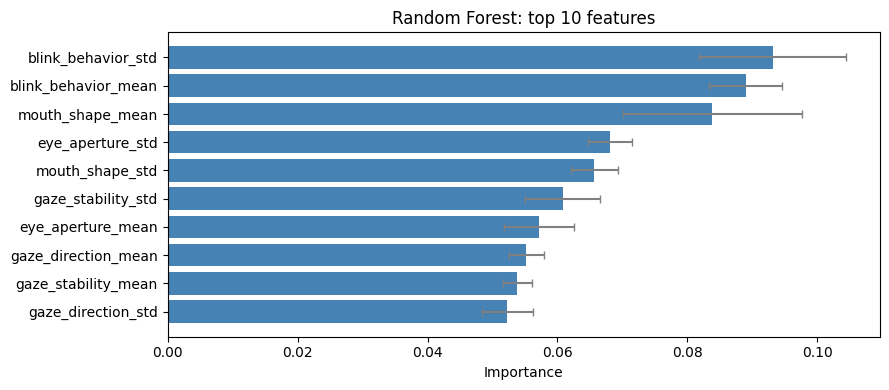

In [33]:
task_importance_long, task_importance_summary = task_feature_importance_cv(
    df_task_all, subset_name="all_video"
)

plot_cv_feature_importance(
    task_importance_summary,
    model_name="Random Forest",
    subset_name="all_video",
    use_signed=False,
    top_n=10,
)

## Pérdida de capacidad discriminatoria en el subconjunto hablado

Esta sección genera una proyección PCA común para comparar el subconjunto completo con el subconjunto hablado (`Counting1`, `Counting2`, `Counting3`, `Math`, `Reading`, `Speaking`, `Stroop`).  


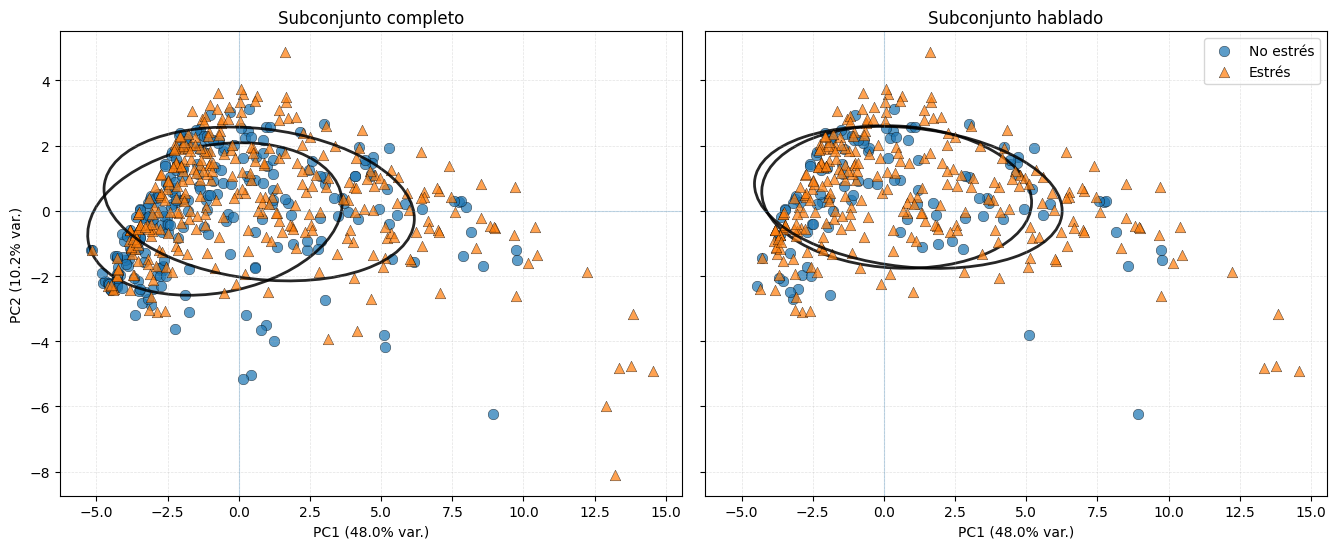

Saved figure:
  figures/pca_visual_cues_all_vs_spoken_all_selected_visual_cues.png
  figures/pca_visual_cues_all_vs_spoken_all_selected_visual_cues.pdf


,feature,PC1_loading,PC2_loading,loading_norm_PC1_PC2,oral_forced_cue
0,gaze_direction_max,0.169572,0.320864,0.362916,False
1,gaze_direction_std,0.159365,0.302985,0.342341,False
2,gaze_stability_mean,0.188949,0.271280,0.330597,False
3,gaze_direction_mean,0.151394,0.288700,0.325987,False
4,mouth_shape_std,0.052605,-0.317258,0.321589,True
5,gaze_stability_max,0.198865,0.248826,0.318530,False
6,gaze_stability_std,0.176043,0.255891,0.310599,False
7,mouth_shape_max,0.178479,-0.225791,0.287813,True
8,lip_corner_tension_std,0.227703,-0.173529,0.286288,True
9,lip_corner_tension_max,0.213183,-0.182890,0.280884,True



Interpretación esperada:
- En el subconjunto completo debería observarse mayor separación entre No estrés/Estrés.
- En el subconjunto hablado, el solapamiento de nubes y el menor valor de separación geométrica indican pérdida de capacidad discriminatoria.
- Si entre las cargas principales aparecen mouth/lip/jaw, el PCA refuerza visualmente que la articulación forzada domina parte del espacio de indicios.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# spoken activities
spoken_activities = [
    "Counting1", "Counting2", "Counting3",
    "Math", "Reading", "Speaking", "Stroop",
]

ORAL_FORCED_CUES = [
    "mouth_shape",
    "lip_pressing",
    "lip_corner_tension",
    "jaw_mouth_tension",
]

USE_ONLY_ORAL_FORCED_CUES = False

model_cue_prefixes = CUE_COLS

if USE_ONLY_ORAL_FORCED_CUES:
    cue_prefixes_for_pca = ORAL_FORCED_CUES
    feature_set_name = "oral_forced_cues_only"
else:
    cue_prefixes_for_pca = model_cue_prefixes
    feature_set_name = "all_selected_visual_cues"

feature_cols = [
    c for c in df_task_all.columns
    if any(c.startswith(prefix + "_") for prefix in cue_prefixes_for_pca)
    and pd.api.types.is_numeric_dtype(df_task_all[c])
]

def activity_from_task_id(value):
    value = str(value)
    return value.split("_", 1)[1] if "_" in value else value

def build_pca_plot_frame(df_task, subset_name, scaler, pca, feature_cols):
    """Transform a task-level dataframe into the common PCA space."""

    meta = df_task[["subject", "subject_activity", "binary-stress"]].copy()
    meta["activity"] = meta["subject_activity"].apply(activity_from_task_id)
    meta["subset"] = subset_name
    meta["y_label"] = meta["binary-stress"].astype(int).map({0: "No estrés", 1: "Estrés"})

    X = df_task[feature_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    coords = pca.transform(scaler.transform(X))
    meta["PC1"] = coords[:, 0]
    meta["PC2"] = coords[:, 1]
    return meta

def add_cov_ellipse(ax, x, y, n_std=1.35, **kwargs):
    """Add a covariance ellipse"""

    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) < 3 or len(y) < 3:
        return

    cov = np.cov(x, y)
    if not np.all(np.isfinite(cov)):
        return

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    if np.any(eigvals <= 0):
        return

    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs,
    )
    ax.add_patch(ellipse)

# Fit scaler and PCA on the full task-level visual-cue space.
# The spoken subset is projected into this same space, which keeps both panels comparable.
X_all = df_task_all[feature_cols].copy()
X_all = X_all.replace([np.inf, -np.inf], np.nan)
X_all = X_all.fillna(X_all.median(numeric_only=True))

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca.fit(X_all_scaled)

plot_all = build_pca_plot_frame(df_task_all, "Subconjunto completo", scaler, pca, feature_cols)
plot_spoken = build_pca_plot_frame(df_task_spoken, "Subconjunto hablado", scaler, pca, feature_cols)

# Main figure: same PCA coordinates, two panels.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), sharex=True, sharey=True)

panels = [
    (axes[0], plot_all, "Subconjunto completo"),
    (axes[1], plot_spoken, "Subconjunto hablado"),
]

markers = {0: "o", 1: "^"}
class_names = {0: "No estrés", 1: "Estrés"}

for ax, data, title in panels:
    for cls in [0, 1]:
        d = data[data["binary-stress"] == cls]
        ax.scatter(
            d["PC1"], d["PC2"],
            s=58,
            alpha=0.72,
            marker=markers[cls],
            label=class_names[cls],
            edgecolor="black",
            linewidth=0.35,
        )
        add_cov_ellipse(ax, d["PC1"], d["PC2"], linewidth=2.0, alpha=0.85)

    pos_rate = data["binary-stress"].mean()
    ax.set_title(title)

    ax.axhline(0, linewidth=0.8, alpha=0.25)
    ax.axvline(0, linewidth=0.8, alpha=0.25)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)")

axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)")
axes[1].legend(loc="best", frameon=True)

fig.tight_layout()

os.makedirs("figures", exist_ok=True)
png_path = f"figures/pca_visual_cues_all_vs_spoken_{feature_set_name}.png"
pdf_path = f"figures/pca_visual_cues_all_vs_spoken_{feature_set_name}.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved figure:\n  {png_path}\n  {pdf_path}")

loading_df = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1_loading", "PC2_loading"],
).reset_index(names="feature")

loading_df["loading_norm_PC1_PC2"] = np.sqrt(
    loading_df["PC1_loading"] ** 2 + loading_df["PC2_loading"] ** 2
)
loading_df["oral_forced_cue"] = loading_df["feature"].apply(
    lambda f: any(f.startswith(prefix + "_") for prefix in ORAL_FORCED_CUES)
)

top_loadings = (
    loading_df
    .sort_values("loading_norm_PC1_PC2", ascending=False)
    .head(12)
    .reset_index(drop=True)
)

display(top_loadings)
